In [118]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [37]:
data = pd.read_html("https://fbref.com/es/comps/9/2023-2024/horario/Marcadores-y-partidos-de-2023-2024-Premier-League",encoding='UTF-8')

In [38]:
data = data[0]

In [39]:
data[['Goles Local', 'Goles Visitante']] = data['Marcador'].str.split('–', expand=True)

In [40]:
data = data.drop('Marcador', axis=1)

In [41]:
import re
def extraer_numero(cadena):
    numeros = re.findall(r'\b\d+\b', str(cadena))
    if numeros:
        return int(numeros[0])
    else:
        return None

In [42]:
data['Goles Local'] = data['Goles Local'].apply(extraer_numero).fillna(0).astype(int)
data['Goles Visitante'] = data['Goles Visitante'].apply(extraer_numero).fillna(0).astype(int)

In [43]:
data = data.reset_index(drop=True)

,Sem.,Día,Fecha,Hora,Local,xG,xG.1,Visitante,Asistencia,Sedes,Árbitro,Informe del partido,Notas,Goles Local,Goles Visitante
0,1.0,Vie,2023-08-11,20:00,Burnley,0.3,1.9,Manchester City,21572.0,Turf Moor,Craig Pawson,Informe del partido,NaN,0,3
1,1.0,Sáb,2023-08-12,12:30,Arsenal,0.8,1.2,Nott'ham Forest,59984.0,Emirates Stadium,Michael Oliver,Informe del partido,NaN,2,1
2,1.0,Sáb,2023-08-12,15:00,Everton,2.7,1.5,Fulham,39940.0,Goodison Park,Stuart Attwell,Informe del partido,NaN,0,1
3,1.0,Sáb,2023-08-12,15:00,Sheffield Utd,0.5,1.9,Crystal Palace,31194.0,Bramall Lane,John Brooks,Informe del partido,NaN,0,1
4,1.0,Sáb,2023-08-12,15:00,Brighton,4.0,1.5,Luton Town,31872.0,The American Express Community Stadium,David Coote,Informe del partido,NaN,4,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
418,38.0,Dom,2024-05-19,16:00,Brentford,1.1,3.4,Newcastle Utd,17124.0,Gtech Community Stadium,Simon Hooper,Informe del partido,NaN,2,4
419,38.0,Dom,2024-05-19,16:00,Chelsea,1.1,2.2,Bournemouth,39724.0,Stamford Bridge,Anthony Taylor,Informe del partido,NaN,2,1
420,38.0,Dom,2024-05-19,16:00,Crystal Palace,2.5,0.9,Aston Villa,25191.0,Selhurst Park,Darren Bond,Informe del partido,NaN,5,0
421,38.0,Dom,2024-05-19,16:00,Liverpool,4.5,0.5,Wolves,60059.0,Anfield,Chris Kavanagh,Informe del partido,NaN,2,0


In [44]:
data2 = pd.read_html("https://fbref.com/es/comps/9/2022-2023/horario/Marcadores-y-partidos-de-2022-2023-Premier-League")

In [45]:
data2 = data2[0]

In [46]:
data2[['Goles Local', 'Goles Visitante']] = data2['Marcador'].str.split('–', expand=True)

In [47]:
data2 = data2.drop('Marcador', axis=1)

In [48]:
data2['Goles Local'] = data2['Goles Local'].apply(extraer_numero).fillna(0).astype(int)
data2['Goles Visitante'] = data2['Goles Visitante'].apply(extraer_numero).fillna(0).astype(int)

In [50]:
data3 = [data,data2]
data3 = pd.concat(data3)

In [51]:
data3 = data3.drop('Notas',axis=1)

In [61]:
data3 = data3.reset_index(drop=True)

In [55]:
condition = (data3.isna().any(axis=1))&((data3 == 0).any(axis=1))
data3 = data3[~condition]

In [58]:
data3=data3.reset_index(drop=True)

In [78]:
data3['Goles Totales'] = data3['Goles Local'] + data3['Goles Visitante']
data4 = data3.groupby('Sem.')['Goles Totales'].sum()

In [92]:
data5 = pd.DataFrame(data4)

<BarContainer object of 38 artists>

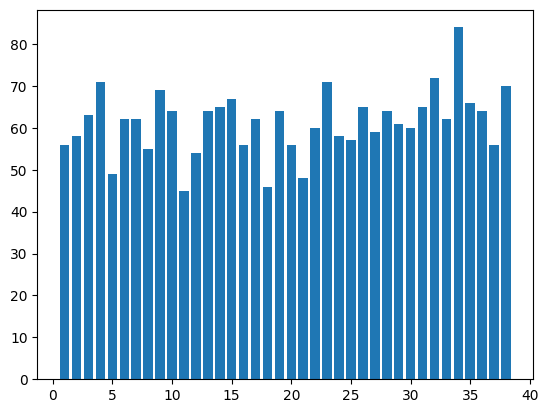

In [105]:
plt.bar(np.arange(1,39,1),data5['Goles Totales'])

In [107]:
data['Goles Totales'] = data['Goles Local'] + data['Goles Visitante']
data6 = data.groupby('Sem.')['Goles Totales'].sum()

<BarContainer object of 38 artists>

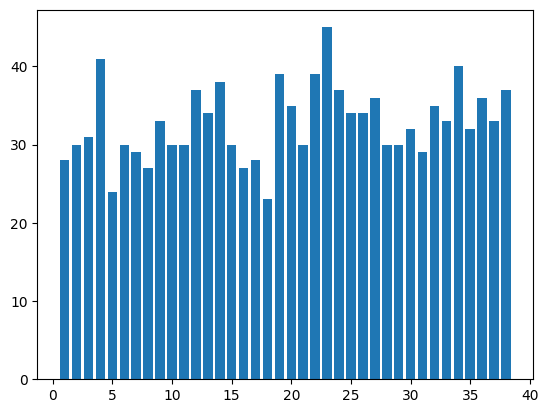

In [110]:
data6 = pd.DataFrame(data6)
plt.bar(np.arange(1,39,1),data6['Goles Totales'])

In [111]:
data6

,Goles Totales
Sem.,
1.0,28
2.0,30
3.0,31
4.0,41
5.0,24
6.0,30
7.0,29
8.0,27
9.0,33


In [117]:
print(data[(data['Sem.']==1.0)]['Goles Totales'].sum()/len(data[(data['Sem.']==1.0)]))

2.8


In [120]:
data7 = pd.read_html("https://fbref.com/es/comps/9/2021-2022/horario/Marcadores-y-partidos-de-2022-2023-Premier-League")

In [122]:
data7 = data7[0]

In [123]:
data7[['Goles Local', 'Goles Visitante']] = data7['Marcador'].str.split('–', expand=True)

In [124]:
data7['Goles Local'] = data7['Goles Local'].apply(extraer_numero).fillna(0).astype(int)
data7['Goles Visitante'] = data7['Goles Visitante'].apply(extraer_numero).fillna(0).astype(int)

In [125]:
data7 = data7.drop('Notas',axis=1)

In [133]:
data7['Goles Totales'] = data7['Goles Local'] + data7['Goles Visitante']

In [134]:
data8 = [data3,data7]
data8 = pd.concat(data8)

In [135]:
data8=data8.reset_index(drop=True)

In [136]:
data8=data8.drop('Marcador',axis=1)

In [142]:
data8[:390]

,Sem.,Día,Fecha,Hora,Local,xG,xG.1,Visitante,Asistencia,Sedes,Árbitro,Informe del partido,Goles Local,Goles Visitante,Goles Totales
0,1.0,Vie,2023-08-11,20:00,Burnley,0.3,1.9,Manchester City,21572.0,Turf Moor,Craig Pawson,Informe del partido,0,3,3
1,1.0,Sáb,2023-08-12,12:30,Arsenal,0.8,1.2,Nott'ham Forest,59984.0,Emirates Stadium,Michael Oliver,Informe del partido,2,1,3
2,1.0,Sáb,2023-08-12,15:00,Everton,2.7,1.5,Fulham,39940.0,Goodison Park,Stuart Attwell,Informe del partido,0,1,1
3,1.0,Sáb,2023-08-12,15:00,Sheffield Utd,0.5,1.9,Crystal Palace,31194.0,Bramall Lane,John Brooks,Informe del partido,0,1,1
4,1.0,Sáb,2023-08-12,15:00,Brighton,4.0,1.5,Luton Town,31872.0,The American Express Community Stadium,David Coote,Informe del partido,4,1,5
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
385,1.0,Sáb,2022-08-06,15:00,Bournemouth,0.6,0.7,Aston Villa,11013.0,Vitality Stadium,Peter Bankes,Informe del partido,2,0,2
386,1.0,Sáb,2022-08-06,17:30,Everton,0.7,1.5,Chelsea,39254.0,Goodison Park,Craig Pawson,Informe del partido,0,1,1
387,1.0,Dom,2022-08-07,14:00,Leicester City,0.6,0.8,Brentford,31794.0,King Power Stadium,Jarred Gillett,Informe del partido,2,2,4
388,1.0,Dom,2022-08-07,14:00,Manchester Utd,1.4,1.5,Brighton,73711.0,Old Trafford,Paul Tierney,Informe del partido,1,2,3


<BarContainer object of 1208 artists>

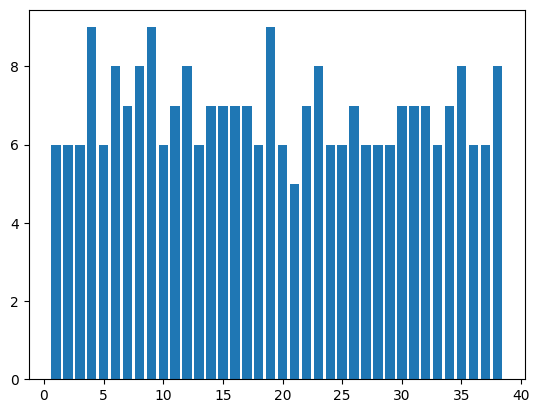

In [138]:
plt.bar(data8['Sem.'],data8['Goles Totales'])

<BarContainer object of 1208 artists>

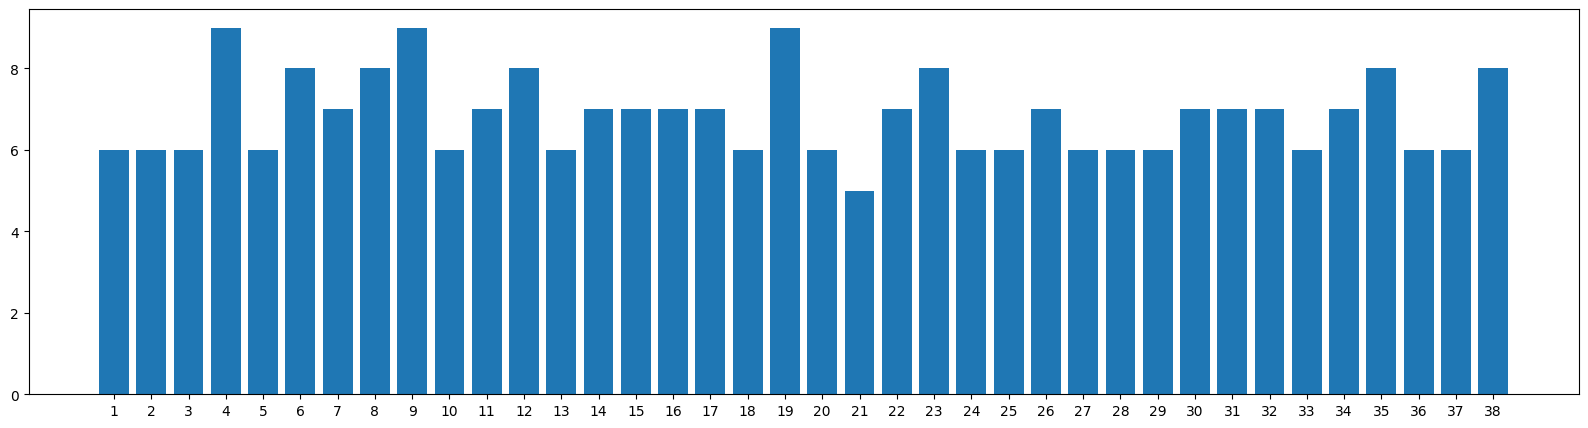

In [155]:
fig, ax = plt.subplots(figsize=(20,5))
ax.set_xticks(np.arange(1,39),labels=np.arange(1,39))
ax.bar(data8['Sem.'],data8['Goles Totales'])

In [166]:
data8[data8['Sem.']==1.0]

,Sem.,Día,Fecha,Hora,Local,xG,xG.1,Visitante,Asistencia,Sedes,Árbitro,Informe del partido,Goles Local,Goles Visitante,Goles Totales
0,1.0,Vie,2023-08-11,20:00,Burnley,0.3,1.9,Manchester City,21572.0,Turf Moor,Craig Pawson,Informe del partido,0,3,3
1,1.0,Sáb,2023-08-12,12:30,Arsenal,0.8,1.2,Nott'ham Forest,59984.0,Emirates Stadium,Michael Oliver,Informe del partido,2,1,3
2,1.0,Sáb,2023-08-12,15:00,Everton,2.7,1.5,Fulham,39940.0,Goodison Park,Stuart Attwell,Informe del partido,0,1,1
3,1.0,Sáb,2023-08-12,15:00,Sheffield Utd,0.5,1.9,Crystal Palace,31194.0,Bramall Lane,John Brooks,Informe del partido,0,1,1
4,1.0,Sáb,2023-08-12,15:00,Brighton,4.0,1.5,Luton Town,31872.0,The American Express Community Stadium,David Coote,Informe del partido,4,1,5
5,1.0,Sáb,2023-08-12,15:00,Bournemouth,1.3,1.1,West Ham,11245.0,Vitality Stadium,Peter Bankes,Informe del partido,1,1,2
6,1.0,Sáb,2023-08-12,17:30,Newcastle Utd,3.3,1.8,Aston Villa,52207.0,St James' Park,Andy Madley,Informe del partido,5,1,6
7,1.0,Dom,2023-08-13,14:00,Brentford,2.2,1.3,Tottenham,17066.0,Gtech Community Stadium,Robert Jones,Informe del partido,2,2,4
8,1.0,Dom,2023-08-13,16:30,Chelsea,1.4,1.3,Liverpool,40096.0,Stamford Bridge,Anthony Taylor,Informe del partido,1,1,2
9,1.0,Lun,2023-08-14,20:00,Manchester Utd,2.2,2.2,Wolves,73358.0,Old Trafford,Simon Hooper,Informe del partido,1,0,1


In [172]:
data9 = {
    'Sem 1':data8[data8['Sem.']==1.0]['Goles Totales'],
    'Sem 2':data8[data8['Sem.']==2.0]['Goles Totales'],
    'Sem 3':data8[data8['Sem.']==3.0]['Goles Totales'],
    'Sem 4':data8[data8['Sem.']==4.0]['Goles Totales'],
    'Sem 5':data8[data8['Sem.']==5.0]['Goles Totales'],
    'Sem 6':data8[data8['Sem.']==6.0]['Goles Totales'],
    'Sem 7':data8[data8['Sem.']==7.0]['Goles Totales'],
    'Sem 8':data8[data8['Sem.']==8.0]['Goles Totales'],
    'Sem 9':data8[data8['Sem.']==9.0]['Goles Totales'],
    'Sem 10':data8[data8['Sem.']==10.0]['Goles Totales'],
    'Sem 11':data8[data8['Sem.']==11.0]['Goles Totales'],
    'Sem 12':data8[data8['Sem.']==12.0]['Goles Totales'],
}

,Sem 1,Sem 2,Sem 3,Sem 4,Sem 5,Sem 6,Sem 7,Sem 8,Sem 9,Sem 10,Sem 11,Sem 12
0,3.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,3.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,1.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,1.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,5.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...
886,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,6.0
887,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,6.0
888,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,4.0
889,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,3.0


<BarContainer object of 30 artists>

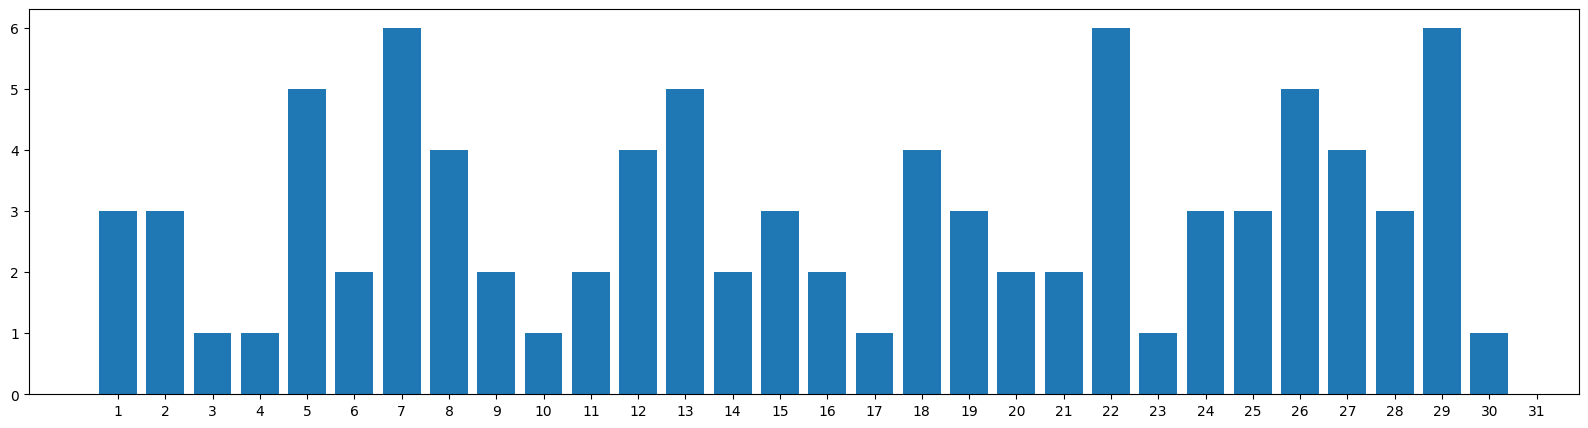

In [189]:
fig, ax = plt.subplots(figsize=(20,5))
ax.set_xticks(np.arange(0,38),labels=np.arange(1,39))
ax.bar(np.arange(0,30),data9['Sem 1'])

In [186]:
data9['Sem 1'].reset_index(drop=True)

0     3
1     3
2     1
3     1
4     5
5     2
6     6
7     4
8     2
9     1
10    2
11    4
12    5
13    2
14    3
15    2
16    1
17    4
18    3
19    2
20    2
21    6
22    1
23    3
24    3
25    5
26    4
27    3
28    6
29    1
Name: Goles Totales, dtype: int64

In [196]:
data8[(data8['Local'].str.contains('Leicester', case=False, na=False)) & (data8['Visitante'].str.contains('Manchester City'))]

,Sem.,Día,Fecha,Hora,Local,xG,xG.1,Visitante,Asistencia,Sedes,Árbitro,Informe del partido,Goles Local,Goles Visitante,Goles Totales
496,14.0,Sáb,2022-10-29,12:30,Leicester City,0.7,1.0,Manchester City,32223.0,King Power Stadium,Robert Jones,Informe del partido,0,1,1
798,4.0,Sáb,2021-09-11,15:00,Leicester City,0.6,2.8,Manchester City,32087.0,King Power Stadium,Paul Tierney,Informe del partido,0,1,1


In [221]:
def filtro(local,visitante):
    data=data8[(data8['Local'].str.contains(local, case=False, na=False)) & (data8['Visitante'].str.contains(visitante))]#filtro para los equipos
    data.loc[:, 'Fecha'] = pd.to_datetime(data['Fecha']).dt.date #se convierte a fecha el .loc es para no copias una columna
    data_sorted=data.sort_values(by='Fecha', ascending=True) #ordena por fecha de forma ascendente
    return data_sorted

In [222]:
filtro('Fulham','Bou')

,Sem.,Día,Fecha,Hora,Local,xG,xG.1,Visitante,Asistencia,Sedes,Árbitro,Informe del partido,Goles Local,Goles Visitante,Goles Totales
469,11.0,Sáb,2022-10-15,15:00,Fulham,2.1,1.0,Bournemouth,22541.0,Craven Cottage,Graham Scott,Informe del partido,2,2,4
232,24.0,Sáb,2024-02-10,15:00,Fulham,1.6,1.8,Bournemouth,24271.0,Craven Cottage,Darren England,Informe del partido,3,1,4


In [223]:
filtro('Tott','Wol')

,Sem.,Día,Fecha,Hora,Local,xG,xG.1,Visitante,Asistencia,Sedes,Árbitro,Informe del partido,Goles Local,Goles Visitante,Goles Totales
1019,25.0,Dom,2022-02-13,14:00,Tottenham,1.2,1.3,Wolves,56452.0,Tottenham Hotspur Stadium,Kevin Friend,Informe del partido,0,2,2
400,3.0,Sáb,2022-08-20,12:30,Tottenham,1.7,0.7,Wolves,61298.0,Tottenham Hotspur Stadium,Simon Hooper,Informe del partido,1,0,1
240,25.0,Sáb,2024-02-17,15:00,Tottenham,1.6,1.8,Wolves,61532.0,Tottenham Hotspur Stadium,Anthony Taylor,Informe del partido,1,2,3


In [ ]:
filtro('','')